In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
symbols = ['D','s','o','v','^','<','x','.','+','1','2','3']
colors = ['tab:blue', 'tab:orange', 'tab:red','tab:cyan', 'tab:green','tab:brown', 
            'teal', 'tab:pink','tab:olive', 'coral', 'tab:gray','gold',
            'tab:purple', 'navy', 'darkgreen', 'maroon', 'steelblue', 'seagreen',
            'indigo', 'crimson', 'forestgreen', 'tomato','slateblue', 'chocolate']

calcfile = './calc-flux-normalized.csv'
data = pd.read_csv(calcfile,sep='\t')
calclabels=data.columns.values
calc = np.array([data[k] for k in calclabels])
reffile = './ref-flux.csv'
refdata = pd.read_csv(reffile,sep='\t')
reflabels=refdata.columns.values
print(calclabels)
ref = np.array([refdata[k] for k in reflabels])
print(calc.shape)
print(ref.shape)

['Timestep' 'J_x' 'J_y' 'J_z' 'Jconv_x' 'Jconv_y' 'Jconv_z' 'Jcond_x'
 'Jcond_y' 'Jcond_z']
(10, 1001)
(10, 1001)


(2, 10)


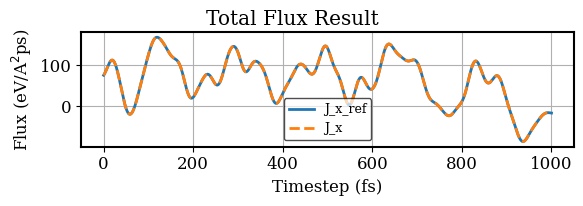

In [ ]:
labels=np.array([calclabels,reflabels])
print(labels.shape)
def plot_xyz(calc,ref=None,xlabel=None,ylabel=None,title=None,labels=None):
    if calc.shape[0] == 2:
        fig, ax = plt.subplots(figsize=(6, 2))
        if ref is not None:
            l=None if labels is None else labels[1,:]
            ax.plot(ref[0], ref[1], label=l, linewidth=2,color=colors[0])
        l=None if labels is None else labels[0,:]
        ax.plot(calc[0], calc[1], label=l, linewidth=2,color=colors[1],linestyle='--')
    ax.set_xlabel(xlabel or f'Timestep')
    ax.set_ylabel(ylabel or f'Flux')
    ax.legend(framealpha=0.7, edgecolor="black",fontsize=9)
    fig.tight_layout()
    fig.suptitle(title or f'Flux Comparison',y=1.02)
    plt.grid(True)
    plt.show()

plot_xyz(calc[:2],ref[:2],xlabel='Timestep (fs)',ylabel='Flux (eV/A$^2$ps)',title='Total Flux Result',labels=labels[[f'Ref J$_t$$_o$_t$',],[' J$_t$$_o$_t$']])

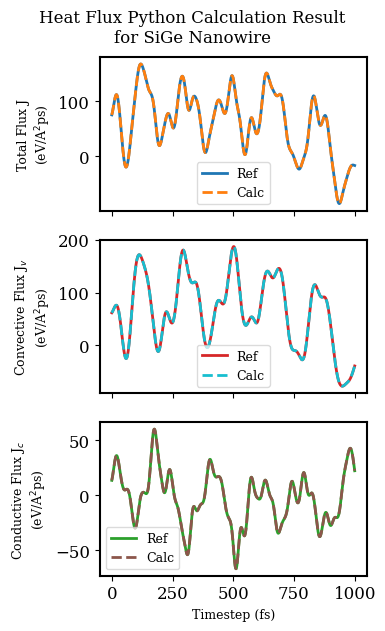

In [45]:
def plot_xyz(calc,ref=None,xlabel=None,ylabel=None,title=None,labels=None):
    fig, (ax,ax1,ax2) = plt.subplots(3,1,sharex=True,figsize=(4, 6))
    ax.plot(ref[0], ref[1], label=labels[1,0], linewidth=2,color=colors[0],linestyle='-')
    ax.plot(calc[0], calc[1], label=labels[0,0], linewidth=2,color=colors[1],linestyle='--')
    ax.legend(framealpha=0.7,fontsize=9)
    ax.set_ylabel(f'Total Flux J\n(eV/A$^2$ps)',fontsize=9)
    ax1.plot(ref[0], ref[2], label=labels[1,1], linewidth=2,color=colors[2],linestyle='-')
    ax1.plot(calc[0], calc[2], label=labels[0,1], linewidth=2,color=colors[3],linestyle='--')
    ax1.legend(framealpha=0.7,fontsize=9)
    ax1.set_ylabel(f'Convective Flux J$_v$\n(eV/A$^2$ps)',fontsize=9)
    ax2.plot(ref[0], ref[3], label=labels[1,2], linewidth=2,color=colors[4],linestyle='-')
    ax2.plot(calc[0], calc[3], label=labels[0,2], linewidth=2,color=colors[5],linestyle='--')
    ax2.legend(framealpha=0.7,fontsize=9)
    ax2.set_ylabel(f'Conductive Flux J$_c$\n(eV/A$^2$ps)',fontsize=9)
    ax2.set_xlabel(xlabel or f'Timestep',fontsize=9)
    fig.tight_layout()
    fig.suptitle(title or f'Flux Comparison',y=1.05,fontsize=12)
    plt.show()
calc_totals = np.array([calc[0],calc[1],calc[4],calc[7]])
ref_totals = np.array([ref[0],ref[1],ref[4],ref[7]])
labels_totals = np.array([[f'Calc',f'Calc',f'Calc'],[f'Ref',f'Ref',f'Ref']])
plot_xyz(calc_totals,ref_totals,xlabel='Timestep (fs)',ylabel='Flux (eV/A$^2$ps)',title=f'Heat Flux Python Calculation Result\nfor SiGe Nanowire',labels=labels_totals)

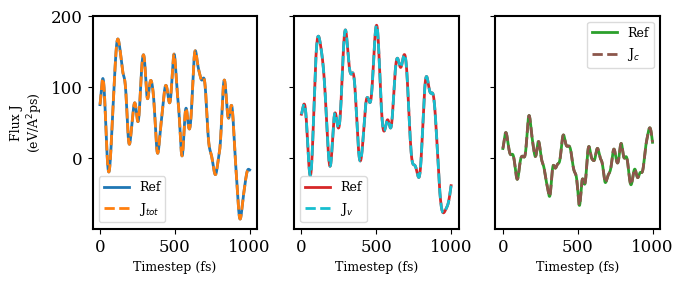

In [7]:
def plot_flux(calc,ref=None,xlabel=None,ylabel=None,title=None,labels=None):
    fig, (ax,ax1,ax2) = plt.subplots(1,3,sharey=True,figsize=(7,3))
    ax.plot(ref[0], ref[1], label=labels[1,0], linewidth=2,color=colors[0],linestyle='-')
    ax.plot(calc[0], calc[1], label=labels[0,0], linewidth=2,color=colors[1],linestyle='--')
    ax.legend(framealpha=0.7,fontsize=9)
    ax.set_ylabel(f'Flux J\n(eV/A$^2$ps)',fontsize=9)
    ax.set_xlabel(xlabel or f'Timestep',fontsize=9)
    ax1.plot(ref[0], ref[2], label=labels[1,1], linewidth=2,color=colors[2],linestyle='-')
    ax1.plot(calc[0], calc[2], label=labels[0,1], linewidth=2,color=colors[3],linestyle='--')
    ax1.legend(framealpha=0.7,fontsize=9)
    # ax1.set_ylabel(f'Convective Flux J$_v$\n(eV/A$^2$ps)',fontsize=9)
    ax1.set_xlabel(xlabel or f'Timestep',fontsize=9)
    ax2.plot(ref[0], ref[3], label=labels[1,2], linewidth=2,color=colors[4],linestyle='-')
    ax2.plot(calc[0], calc[3], label=labels[0,2], linewidth=2,color=colors[5],linestyle='--')
    ax2.legend(framealpha=0.7,fontsize=9)
    # ax2.set_ylabel(f'Conductive Flux J$_c$\n(eV/A$^2$ps)',fontsize=9)
    ax2.set_xlabel(xlabel or f'Timestep',fontsize=9)
    fig.tight_layout()
    fig.suptitle(title,y=1.05,fontsize=12)
    plt.show()
calc_totals = np.array([calc[0],calc[1],calc[4],calc[7]])
ref_totals = np.array([ref[0],ref[1],ref[4],ref[7]])
labels_totals = np.array([['J$_{tot}$',f'J$_v$',f'J$_c$'],[f'Ref',f'Ref',f'Ref']])
plot_flux(calc_totals,ref_totals,xlabel='Timestep (fs)',ylabel='Flux (eV/A$^2$ps)',title=None,labels=labels_totals)

In [6]:
# RELATIVE ERROR FORMULATION CALCULATION AND VISUALIZATION FUNCTIONS
def compute_relative_error(calcdata,refdata):
    numerator = abs(refdata - calcdata)
    denom = np.where(refdata != 0, abs(refdata), abs(calcdata))
    error = np.where(denom != 0, numerator / denom, 0.0)
    print(f'max error = {np.nanmax(error)}')
    return error

def plot_relative_error(error, xlabel="X-Axis", title="Relative Error", components=None):
    x = np.arange(error.shape[0])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, error, label='total error', color='k', linewidth=1, marker='|')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"Error")
    ax.set_title(title)
    ax.legend(framealpha=0.7, edgecolor="black",fontsize=9)
    fig.tight_layout()
    plt.show()


In [ ]:

    # elif calc[2,1]/calc[1,1] < 0.05:
    #     fig, (ax0,ax) = plt.subplots(2,1,sharex=True,figsize=(6, 6))
    #     if ref is not None:
    #         l=[f'ref_x',f'ref_y',f'ref_z'] if labels is None else labels[1,:]
    #         ax0.plot(ref[0], ref[1], label=l[0], linewidth=1,color=colors[0])
    #         ax.plot(ref[0], ref[2]*np.max(calc[2])/np.max(ref[2]), label=l[1], linewidth=1,color=colors[1])
    #         ax.plot(ref[0], ref[3]*np.max(calc[3])/np.max(ref[3]), label=l[2], linewidth=1,color=colors[2])
    #     l=['x','y','z'] if labels is None else labels[0,:]
    #     ax0.plot(calc[0], calc[1], label=l[0], linewidth=1,color=colors[3],linestyle='--')
    #     ax.plot(calc[0], calc[2], label=l[1], linewidth=1,color=colors[4],linestyle='--')
    #     ax.plot(calc[0], calc[3], label=l[2], linewidth=1,color=colors[5],linestyle='--')
    #     ax0.legend(framealpha=0.7, edgecolor="black",fontsize=9)
    #     ax0.set_ylabel(ylabel or f'Flux')
    # else:
    #     fig, ax = plt.subplots(figsize=(6, 4))
    #     if ref is not None:
    #         l=[f'ref_x',f'ref_y',f'ref_z'] if labels is None else labels[1,:]
    #         for i in range(ref.shape[0]-1) if ref.shape[0] > 2 else 0:
    #             ax.plot(ref[0], ref[i+1], label=l[i], linewidth=1,color=colors[i])
    #     l=['x','y','z'] if labels is None else labels[0,:]
    #     for j in range(calc.shape[0]-1) if calc.shape[0] > 2 else 0:
    #         ax.plot(calc[0], calc[j+1], label=l[j], linewidth=1,color=colors[i+j+1],linestyle='--')